# MMLU Benchmark

# Setup

In [1]:
from concurrent.futures import ThreadPoolExecutor
import csv
import json
import os
from pathlib import Path
from random import sample
import shutil
import tarfile
import tempfile
from typing import Callable, Iterator, Mapping, NamedTuple, Sequence, override

from llama_models.llama3.api import Tokenizer
from llama_models.llama3.reference_impl.model import RMSNorm
import numpy as np
from pandas import DataFrame
import requests
from rich.progress import Progress
import torch
from torch import Tensor, nn
from torch.nn import functional as F
from tqdm import trange

In [2]:
# Configure
project_path = Path(os.environ["PROJECT_ROOT"])
datasets_path = project_path / ".build" / "datasets"
dataset_path = datasets_path / "mmlu"
work_dir = tempfile.TemporaryDirectory()
work_path = Path(work_dir.name)
executor = ThreadPoolExecutor()

# Generic Tools

In [3]:
def default_arg[T](
    v: T,
    default: T | None = None,
    default_factory: Callable[[], T] | None = None,
):
    """Populate default parameters."""
    if v is not None:
        return v

    if default is None and default_factory is not None:
        return default_factory()

    return default

# MMLU Dataset

The Massive Multitask Language Understanding (MMLU) benchmark dataset from https://github.com/hendrycks/test contains 14,042 MCQs from 57 categories. Each question has 4 options A, B, C, and D and one correct answer. In addition, each category has 5 example questions designed for few-shot experiments.

## Code

In [4]:
class Question(NamedTuple):
    """Represents an MMLU question."""

    qid: int
    category: str
    question: str
    A: str
    B: str
    C: str
    D: str
    answer: str


class Answer(NamedTuple):
    """Represents an answer to MMLU question."""

    qid: int

    expected: str

    actual: str

    scores: dict[str, float]

    correct: bool


OPTIONS = tuple(["A", "B", "C", "D"])
Questions = Sequence[Question]
Answers = Sequence[Answer]

def download_dataset(work_path: Path, output_path: Path):

    # Check if it exists already
    if output_path.exists():
        print(f"Dataset {output_path.name} exists. Skipping.")
        return
    
    dataset_url = "https://people.eecs.berkeley.edu/~hendrycks/data.tar"

    # Download tarball
    response = requests.get(dataset_url, stream=True)
    total = int(response.headers["Content-Length"])
    
    with Progress() as progress, tempfile.NamedTemporaryFile() as tarball:
        task = progress.add_task("Downloading...", total=total)

        for data in response.iter_content(chunk_size=5*1024*1024):
            tarball.write(data)            
            progress.update(task, advance=len(data), refresh=True)
        
        with tarfile.open(tarball.name) as tf:
            tf.extractall(work_path, filter="data")
        
        shutil.move(work_path / "data", output_path)

        
def load_dataset(dataset_path: Path) -> tuple[Questions, Questions]:
    """Load MMLU examples and questions."""
    
    def load_data_file(path: Path) -> Questions:        
        # Infer category from file name: x_y_z_test.csv -> x y z
        category = " ".join(path.stem.split("_")[0:-1])
    
        with open(path, mode="r", encoding="utf-8") as csv_file:
            reader = csv.reader(csv_file)
            questions = tuple(Question(i, category, *row) for i, row in enumerate(reader))
    
        return questions

    def load_segment(segment: str) -> Questions:
        # Sort paths to ensure consistent order
        paths = sorted(path for path in dataset_path.glob(f"{segment}/*.csv"))
    
        # Load data files in parallel
        futures = [executor.submit(load_data_file, path) for path in paths]
    
        # Collect results
        collected = ()
        for future in futures:
            collected += future.result()
    
        # Reassign ids
        questions = ()
        for i, question in enumerate(collected):
            questions += (Question(i, *question[1:]),)
    
        return questions

    examples = load_segment("dev")
    questions = load_segment("test")

    return examples, questions


def show_questions(questions: Questions):
    display(DataFrame(questions))

## Load Dataset

In [5]:
# Download dataset if needed
download_dataset(work_path, dataset_path)

Dataset mmlu exists. Skipping.


In [6]:
examples, questions = load_dataset(dataset_path)
print(f"Loaded {len(examples)} examples, {len(questions)} questions")

Loaded 285 examples, 14042 questions


# Prompting

We combine each question with the relevant examples to generate few-shot prompts. The prompt template is based on the one used by Hendrycks et al. (2021) and implemented at https://github.com/hendrycks/test.

## Code

In [7]:
def generate_prompt(
    question: Question,
    *,
    n_shots: int | None = None,
    examples: Questions | None = None,
    header: bool | None = None,
):
    """Generate prompt for specified question."""
    # Defaults
    n_shots = default_arg(n_shots, 0)
    header = default_arg(header, True)

    # Validate
    if n_shots > 0 and examples is None:
        raise ValueError("n_shots specified without examples")

    selected_examples = None
    if n_shots > 0:
        # Select examples for category
        selected_examples = [e for e in examples if e.category == question.category]

        # Deterministically select n_shots if specified
        selected_examples = selected_examples[:n_shots]

    content = ""

    # Start with examples
    if header:
        content += f"The following are multiple choice questions (with answers) about {question.category}.\n\n"

    if selected_examples:
        for row in selected_examples:
            content += f"Question: {row.question}\n\nA) {row.A}\nB) {row.B}\nC) {row.C}\nD) {row.D}\n\nAnswer: {row.answer}\n\n"

    # Pose question
    content += (
        f"Question: {question.question}\n"
        f"\n"
        f"A) {question.A}\n"
        f"B) {question.B}\n"
        f"C) {question.C}\n"
        f"D) {question.D}\n"
        f"\n"
        f"Answer: "
    )

    return content

## 1-Shot Prompt Example

In [8]:
prompt = generate_prompt(sample(questions, k=1)[0], n_shots=1, examples=examples, header=True)
print(prompt)

The following are multiple choice questions (with answers) about high school biology.

Question: Which of the following is not a way to form recombinant DNA?

A) Translation
B) Conjugation
C) Specialized transduction
D) Transformation

Answer: A

Question: The frequency of a particular allele in a population of 1,000 birds in Hardy-Weinberg equilibrium is 0.3. If the population remains in equilibrium, what would be the expected frequency of that allele after 500 years?

A) It will increase if the allele is favorable or will decrease if it is unfavorable for individuals in that population.
B) Not enough information is provided to determine if the frequency of the allele will remain the same or change.
C) The frequency of the allele will remain at 0.3 because the population is at Hardy-Weinberg equilibrium.
D) The frequency of the allele will remain the same; this is an example of the bottleneck effect.

Answer: 


# Generating Answers

## Code

In [9]:
def torch_device() -> torch.device:
    """Configure gpus."""
    if torch.cuda.is_available():
        return torch.device("cuda")

    if torch.backends.mps.is_available():
        return torch.device("mps")

    return torch.device("cpu")


class ModelConfig(NamedTuple):
    """Llama3 model config."""

    checkpoint_path: Path

    vocab_size: int

    d_model: int

    d_head: int

    d_ffn: int

    n_layers: int

    n_heads: int

    n_kv_heads: int

    rms_norm_eps: float

    rope_theta: float


def load_config(checkpoint_name: str, **kwargs) -> ModelConfig:
    """Load Llama3 config from checkpoint params.json."""
    # Build checkpoint_path
    checkpoints_path = Path("~/.llama/checkpoints").expanduser()
    checkpoint_path = checkpoints_path / checkpoint_name

    # Load hyperparameters
    hparams_path = checkpoint_path / "params.json"
    hparams = json.loads(hparams_path.read_text())

    # Calculate d_ffn from 8/3 * d_model rounded to nearest multiple_of
    d_model = hparams["dim"]
    ffn_dim_multiplier = hparams["ffn_dim_multiplier"]
    multiple_of = hparams["multiple_of"]
    d_ffn = int(8 / 3 * d_model * ffn_dim_multiplier)
    d_ffn = multiple_of * ((d_ffn + multiple_of - 1) // multiple_of)

    data = {
        "checkpoint_path": checkpoint_path,
        "vocab_size": hparams["vocab_size"],
        "d_model": hparams["dim"],
        "n_layers": hparams["n_layers"],
        "rms_norm_eps": hparams["norm_eps"],
        "n_heads": hparams["n_heads"],
        "d_head": int(hparams["dim"] / hparams["n_heads"]),
        "n_kv_heads": hparams["n_kv_heads"],
        "rope_theta": hparams["rope_theta"],
        "d_ffn": d_ffn,
    }

    # Override with kwargs
    data |= kwargs

    return ModelConfig(**data)


ModelParameters = Mapping[str, Tensor]
"""Maps parameter names to weights."""


def load_parameters(config: ModelConfig, **kwargs) -> ModelParameters:
    """Load model state from checkpoint."""
    # Load state from checkpoint
    checkpoint_params = torch.load(
        config.checkpoint_path / "consolidated.00.pth",
        weights_only=True,
        **kwargs,
    )

    # Remap Meta's parameter names
    params = {}

    # Embeddings
    params |= {
        "model.embeddings.weight": checkpoint_params["tok_embeddings.weight"],
    }

    # Layers
    for layer_id in range(config.n_layers):
        params |= {
            f"model.layers.{layer_id}.attention.normalize.weight": checkpoint_params[
                f"layers.{layer_id}.attention_norm.weight"
            ],
            f"model.layers.{layer_id}.attention.w_queries.weight": checkpoint_params[
                f"layers.{layer_id}.attention.wq.weight"
            ],
            f"model.layers.{layer_id}.attention.w_keys.weight": checkpoint_params[
                f"layers.{layer_id}.attention.wk.weight"
            ],
            f"model.layers.{layer_id}.attention.w_values.weight": checkpoint_params[
                f"layers.{layer_id}.attention.wv.weight"
            ],
            f"model.layers.{layer_id}.attention.w_output.weight": checkpoint_params[
                f"layers.{layer_id}.attention.wo.weight"
            ],
            f"model.layers.{layer_id}.ffn.normalize.weight": checkpoint_params[f"layers.{layer_id}.ffn_norm.weight"],
            f"model.layers.{layer_id}.ffn.w_input.weight": checkpoint_params[
                f"layers.{layer_id}.feed_forward.w3.weight"
            ],
            f"model.layers.{layer_id}.ffn.w_gate.weight": checkpoint_params[
                f"layers.{layer_id}.feed_forward.w1.weight"
            ],
            f"model.layers.{layer_id}.ffn.w_output.weight": checkpoint_params[
                f"layers.{layer_id}.feed_forward.w2.weight"
            ],
        }

    # Head
    params |= {
        "head.normalize.weight": checkpoint_params["norm.weight"],
        "head.w_output.weight": checkpoint_params["output.weight"],
    }

    return params


def load_tokenizer(config: ModelConfig) -> Tokenizer:
    """Load tokenizer from checkpoint."""
    # Load tiktoken model
    return Tokenizer(str(config.checkpoint_path / "tokenizer.model"))


class LlamaEmbeddings(nn.Embedding):
    """Llama token embeddings layer."""

    def __init__(self, config: ModelConfig, device: torch.device):
        super().__init__(
            num_embeddings=config.vocab_size,
            embedding_dim=config.d_model,
            device=device,
        )


def rope_frequencies(config: ModelConfig, device: torch.device, n: int):
    """Compute RoPE cos and sin rotation matrices."""
    # Hyperparameters
    base = config.rope_theta
    d = config.d_head

    # Calculate thetas
    i = torch.arange(d // 2, device=device)
    thetas = base ** (-2 * i / d)

    # Duplicate each theta, e.g. [theta_0, theta_1] -> [theta_0, theta_0, theta_1, theta_1]
    thetas = thetas.repeat_interleave(2)

    # Repeat thetas for each position from 0 to n and stack in an (n, d_head) matrix
    theta_stack = torch.stack([m * thetas for m in range(n)])

    # Apply cos, sin
    r_cos = torch.cos(theta_stack)
    r_sin = torch.sin(theta_stack)

    # Sanity check
    assert r_cos.shape[0] == n and r_cos.shape[1] == config.d_head  # noqa: PT018
    assert r_sin.shape[0] == n and r_sin.shape[1] == config.d_head  # noqa: PT018

    return r_cos, r_sin


def rope_swap(x):
    """Maps [x0, x1, x2, x3] -> [-x1, x0, -x3, x2]."""
    # Preserve original shape
    s = x.shape

    # Split into pairs, swap, and restore shape
    x = x.reshape(-1, 2).flip(-1).view(s)

    # Multiply every even index along the last dimension by -1
    #   e.g. [x0, x1, x2, x3] -> [-x0, x1, -x2, x3]
    x[..., ::2] *= -1

    return x


def rope_rotate(x, r_cos, r_sin):
    """Rotate embeddings using RoPE transform."""
    return (x * r_cos) + (rope_swap(x) * r_sin)


class LlamaAttention(nn.Module):
    """Llama attention layer."""

    def __init__(self, config: ModelConfig, device: torch.device):
        super().__init__()

        self.config = config

        # Input normalization
        self.normalize = RMSNorm(
            config.d_model,
            config.rms_norm_eps,
        ).to(device)

        # Queries projection
        self.w_queries = nn.Linear(
            in_features=config.d_model,
            out_features=config.n_heads * config.d_head,
            bias=False,
            device=device,
        )

        # Keys projection
        self.w_keys = nn.Linear(
            in_features=config.d_model,
            out_features=config.n_kv_heads * config.d_head,
            bias=False,
            device=device,
        )

        # Values projection
        self.w_values = nn.Linear(
            in_features=config.d_model,
            out_features=config.n_kv_heads * config.d_head,
            bias=False,
            device=device,
        )

        # Output projection
        self.w_output = nn.Linear(
            in_features=config.d_model,
            out_features=config.d_model,
            bias=False,
            device=device,
        )

    @override
    def forward(self, x: Tensor, r_cos: Tensor, r_sin: Tensor) -> Tensor:
        # Match input device
        device = x.device

        # Save residuals
        residual = x

        # Normalize inputs
        x = self.normalize(x)

        # Project inputs to query, key, value spaces
        q = self.w_queries(x)
        k = self.w_keys(x)
        v = self.w_values(x)

        # Split attention heads
        q = self._split_heads(q, self.config.n_heads)
        k = self._split_heads(k, self.config.n_kv_heads)
        v = self._split_heads(v, self.config.n_kv_heads)

        # Expand key/value groups
        reps = self.config.n_heads // self.config.n_kv_heads
        k = k.repeat_interleave(reps, dim=0)
        v = v.repeat_interleave(reps, dim=0)

        # Encode positions by rotating queries and keys
        q = rope_rotate(q, r_cos, r_sin)
        k = rope_rotate(k, r_cos, r_sin)

        # Compute masked attention bias M
        n = len(x)
        mask = torch.ones(n, n, dtype=torch.bool, device=device).tril(diagonal=0)
        m = torch.zeros(n, n, device=device).masked_fill_(mask.logical_not(), float("-inf"))

        # Compute attention for all heads in parallel
        scores = q @ k.transpose(-2, -1) / np.sqrt(self.config.d_head) + m
        a = F.softmax(scores, dim=-1) @ v

        # Combine attention heads
        a = self._combine_heads(a)

        # Project outputs back to model space
        a = self.w_output(a)

        # Merge outputs with residuals
        x = residual + a

        return x

    def _split_heads(self, x: Tensor, n_heads: int):
        """Split attention heads."""
        return x.view(-1, n_heads, self.config.d_head).transpose(-3, -2)

    def _combine_heads(self, x):
        """Combine attention heads."""
        return x.transpose(-3, -2).contiguous().view(-1, int(self.config.n_heads * self.config.d_head))


class LlamaFFN(nn.Module):
    """Llama feed-forward network."""

    def __init__(self, config: ModelConfig, device: torch.device):
        super().__init__()

        # Input normalization
        self.normalize = RMSNorm(
            config.d_model,
            config.rms_norm_eps,
        ).to(device)

        # Input projection
        self.w_input = nn.Linear(
            in_features=config.d_model,
            out_features=config.d_ffn,
            bias=False,
            device=device,
        )

        # Gate projection
        self.w_gate = nn.Linear(
            in_features=config.d_model,
            out_features=config.d_ffn,
            bias=False,
            device=device,
        )

        # Output projection
        self.w_output = nn.Linear(
            in_features=config.d_ffn,
            out_features=config.d_model,
            bias=False,
            device=device,
        )

    @override
    def forward(self, x: Tensor) -> Tensor:
        # Save residuals
        residual = x

        # Normalize inputs
        x = self.normalize(x)

        # Apply SwiGLU transform
        f = F.silu(self.w_gate(x)) * self.w_input(x)

        # Project outputs back to model space
        f = self.w_output(f)

        # Merge outputs with residuals
        x = residual + f

        return x


class LlamaLayer(nn.Module):
    """Llama transformer layer."""

    def __init__(self, config: ModelConfig, device: torch.device):
        super().__init__()

        self.attention = LlamaAttention(config, device)

        self.ffn = LlamaFFN(config, device)

    @override
    def forward(self, x: Tensor, r_cos: Tensor, r_sin: Tensor) -> Tensor:
        # Attention
        x = self.attention(x, r_cos, r_sin)

        # FFN
        x = self.ffn(x)

        return x


class LlamaModel(nn.Module):
    """Combines embeddings and layers in reusable module."""

    def __init__(self, config: ModelConfig, device: torch.device):
        super().__init__()

        self.config = config

        self.embeddings = LlamaEmbeddings(config, device)

        self.layers = nn.ModuleList(LlamaLayer(config, device) for _ in range(config.n_layers))

    @override
    def forward(self, token_ids: Tensor) -> Tensor:
        # Match input device
        device = token_ids.device

        # Compute cos and sin rotation matrices once for entire sequence
        r_cos, r_sin = rope_frequencies(self.config, device, len(token_ids))

        # Map tokens to embeddings
        x = self.embeddings(token_ids)

        # Transform token embeddings to semantic embeddings
        for layer in self.layers:
            x = layer(x, r_cos, r_sin)

        return x


class LlamaHead(nn.Module):
    """Llama prediction head."""

    def __init__(self, config: ModelConfig, device: torch.device):
        super().__init__()

        # Input normalization
        self.normalize = RMSNorm(
            config.d_model,
            config.rms_norm_eps,
        ).to(device)

        # Output projection
        self.w_output = nn.Linear(
            in_features=config.d_model,
            out_features=config.vocab_size,
            bias=False,
            device=device,
        )

    @override
    def forward(self, x: Tensor) -> Tensor:
        # Normalize inputs
        x = self.normalize(x)

        # Use last embedding to represent the entire sequence
        x = x[-1]

        # Project outputs to token space
        x = self.w_output(x)

        return x


class MMLULlamaHead(LlamaHead):
    """Custom Llama head for MMLU."""

    def __init__(self, config: ModelConfig, device: torch.device, tokenizer: Tokenizer):
        super().__init__(config, device)

        # Calculate token ids for each MMLU option        
        self.token_ids = {option: tokenizer.encode(option, bos=False, eos=False)[0] for option in OPTIONS}

    def forward(self, x: Tensor) -> Mapping[str, float]:
        # Project semantic embeddings to token space
        x = super().forward(x)

        # Select logits for MMLU options
        logits = torch.tensor([x[self.token_ids[option]] for option in OPTIONS], device=x.device)

        # Convert to scores
        scores = F.softmax(logits, dim=-1)

        # Map options to scores
        scores = {option: scores[i] for i, option in enumerate(OPTIONS)}

        # Convert scores back to floats
        scores = {k: v.item() for k, v in scores.items()}

        return scores


class MMLULlamaGenerator(nn.Module):

    def __init__(self, config: ModelConfig, device: torch.device):
        super().__init__()

        self.device = device
        
        self.tokenizer = load_tokenizer(config)
        
        self.model = LlamaModel(config, device)

        self.head = MMLULlamaHead(config, device, self.tokenizer)

    def __call__(
        self,
        questions: Questions,
        n_shots: int | None = None,
        examples: Questions | None = None,
    ) -> Iterator[Answer]:
        """Generate answers."""
        
        # Prepare models
        self.model.eval()
        self.head.eval()

        with torch.no_grad():
            
            for question in questions:
                
                # Generate prompt
                prompt = generate_prompt(question, n_shots=n_shots, examples=examples)
                
                # Split raw text into tokens
                token_ids = self.tokenizer.encode(prompt, bos=True, eos=False)

                # Load token ids into a tensor
                x = torch.tensor(token_ids, device=self.device)

                # Transform tokens into semantic embeddings
                x = self.model(x)
        
                # Score MMLU options
                scores = self.head(x)
        
                # Calculate answer
                actual = max(scores, key=scores.get)

                # Yield answer
                yield Answer(
                    qid=question.qid,
                    expected=question.answer,
                    actual=actual,
                    scores=scores,
                    correct=(actual == question.answer),
                )

# Llama 3.2 3B

In [10]:
config = load_config("Llama3.2-3B")
device = torch_device()

In [11]:
generator = MMLULlamaGenerator(config, device)
generator.load_state_dict(load_parameters(config, map_location=device))

<All keys matched successfully>

## Parameters

In [12]:
n_iterations = 1
n_questions = 16

## Zero to 5 Shot

In [14]:
metrics = {
    0: [],
    1: [],
    2: [],
    3: [],
    4: [],
    5: [],
}

for _ in range(n_iterations):

    # Sample questions
    q = sample(questions, k=n_questions)

    for n_shots in trange(6):
        answers = tuple(generator(q, n_shots=n_shots, examples=examples))
        correct = tuple(a for a in answers if a.correct)
        score = len(correct) / len(answers)
        metrics[n_shots].append(score)


00%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:50<00:00,  8.48s/it]

In [15]:
from matplotlib import pyplot as plt

{'whiskers': [<matplotlib.lines.Line2D at 0x6a7a47680>,
 'caps': [<matplotlib.lines.Line2D at 0x6a78fd8b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x17f4925d0>,
 'medians': [<matplotlib.lines.Line2D at 0x6a7c1c590>,
 'fliers': [<matplotlib.lines.Line2D at 0x6a7c1c8c0>,
 'means': []}

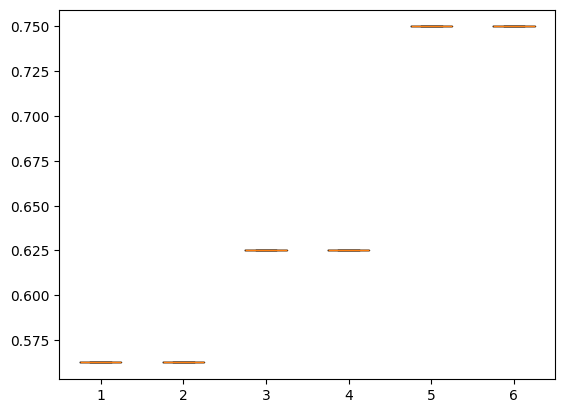

In [16]:
plt.boxplot([metrics[k] for k in range(6)])